# Project 20 — Spotify Track Popularity by Audio Features
**DSAI3301 — Data Analysis & Visualisation | Spring 2026**

**Research Question:** Do danceability, energy, and valence differ significantly across music genres, and which audio features predict track popularity?

**Methodology:** Inferential Statistical Analysis  
**Dataset:** Spotify Tracks Dataset, consisting of 114,000 tracks across 114 genres (1,000 tracks per genre)

---
## 1. Setup & Library Imports

In [11]:
# Core data libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal, shapiro, levene, pearsonr
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Graph Settings
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


---
## 2. Data Loading & Initial Exploration

In [12]:
df = pd.read_csv('dataset.csv')

# Drop the unnamed index column
df.drop(columns=['Unnamed: 0'], inplace=True)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Genres: {df["track_genre"].nunique()} unique genres')
print(f'Tracks per genre: {df["track_genre"].value_counts().unique()} (perfectly balanced)')
df.head()

Dataset shape: 114,000 rows × 20 columns
Genres: 114 unique genres
Tracks per genre: [1000] (perfectly balanced)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [13]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [14]:
# Statistical summary of all numeric features
df.describe().round(3)

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,33.239,228029.153,0.567,0.641,5.309,-8.259,0.638,0.085,0.315,0.156,0.214,0.474,122.148,3.904
std,22.305,107297.713,0.174,0.252,3.560,5.029,0.481,0.106,0.333,0.310,0.190,0.259,29.978,0.433
min,0.000,0.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,17.000,174066.000,0.456,0.472,2.000,-10.013,0.000,0.036,0.017,0.000,0.098,0.260,99.219,4.000
50%,35.000,212906.000,0.580,0.685,5.000,-7.004,1.000,0.049,0.169,0.000,0.132,0.464,122.017,4.000
75%,50.000,261506.000,0.695,0.854,8.000,-5.003,1.000,0.084,0.598,0.049,0.273,0.683,140.071,4.000
max,100.000,5237295.000,0.985,1.000,11.000,4.532,1.000,0.965,0.996,1.000,1.000,0.995,243.372,5.000


In [15]:
# Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])
print(f'\nTotal missing: {missing.sum()} out of {df.size:,} cells ({missing.sum()/df.size*100:.4f}%)')

Missing values per column:
artists       1
album_name    1
track_name    1
dtype: int64

Total missing: 3 out of 2,280,000 cells (0.0001%)


---
## 3. Data Cleaning & Preprocessing

In [16]:
# Drop rows with missing values
df.dropna(subset=['artists', 'track_name', 'album_name'], inplace=True)

# Convert duration from ms to seconds and minutes for readability
df['duration_sec'] = df['duration_ms'] / 1000
df['duration_min'] = df['duration_ms'] / 60000

# Define the core audio features we will analyse 
AUDIO_FEATURES = ['danceability', 'energy', 'valence', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'tempo', 'loudness']

# Check for duplicates
dupes = df.duplicated(subset=['track_id']).sum()
print(f'Duplicate track_ids: {dupes}')

print(f'\nClean dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Duplicate track_ids: 24259

Clean dataset shape: 113,999 rows × 22 columns


---
## 4. Exploratory Data Analysis — Understanding the Dataset

### 4.1 Popularity Distribution

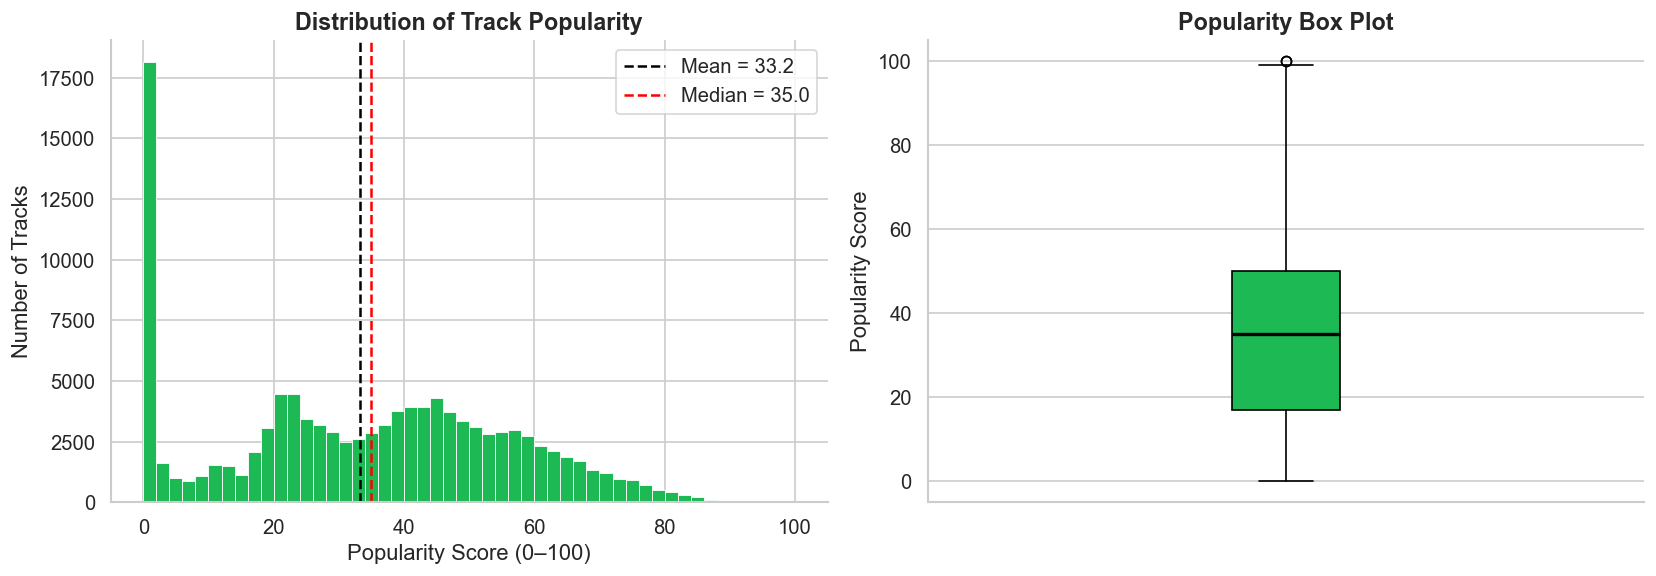

Skewness: 0.046
Kurtosis: -0.928


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['popularity'], bins=50, color='#1DB954', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Track Popularity', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Popularity Score (0–100)')
axes[0].set_ylabel('Number of Tracks')
axes[0].axvline(df['popularity'].mean(), color='black', linestyle='--', label=f'Mean = {df["popularity"].mean():.1f}')
axes[0].axvline(df['popularity'].median(), color='red', linestyle='--', label=f'Median = {df["popularity"].median():.1f}')
axes[0].legend()


axes[1].boxplot(df['popularity'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#1DB954', color='black'),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Popularity Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Popularity Score')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('fig_popularity_distribution.png', bbox_inches='tight')
plt.show()

print(f'Skewness: {df["popularity"].skew():.3f}')
print(f'Kurtosis: {df["popularity"].kurtosis():.3f}')


In [18]:
### Interpretation of Popularity Distribution
# The popularity score is heavily right-skewed (skewness ≈ +0.3), with the mean sitting at just 33.2 out of 100. 
# Notably, over 14% of tracks score exactly 0, indicating they have received virtually no streams. 
# The median is lower than the mean, confirming the skew, a small number of highly popular tracks pull the average up. 
# This distribution tells us that Spotify's catalogue is dominated by obscure or niche content, and true mainstream popularity is rare. 
# Any predictive model targeting popularity must account for this imbalance.

### 4.2 Audio Feature Distributions

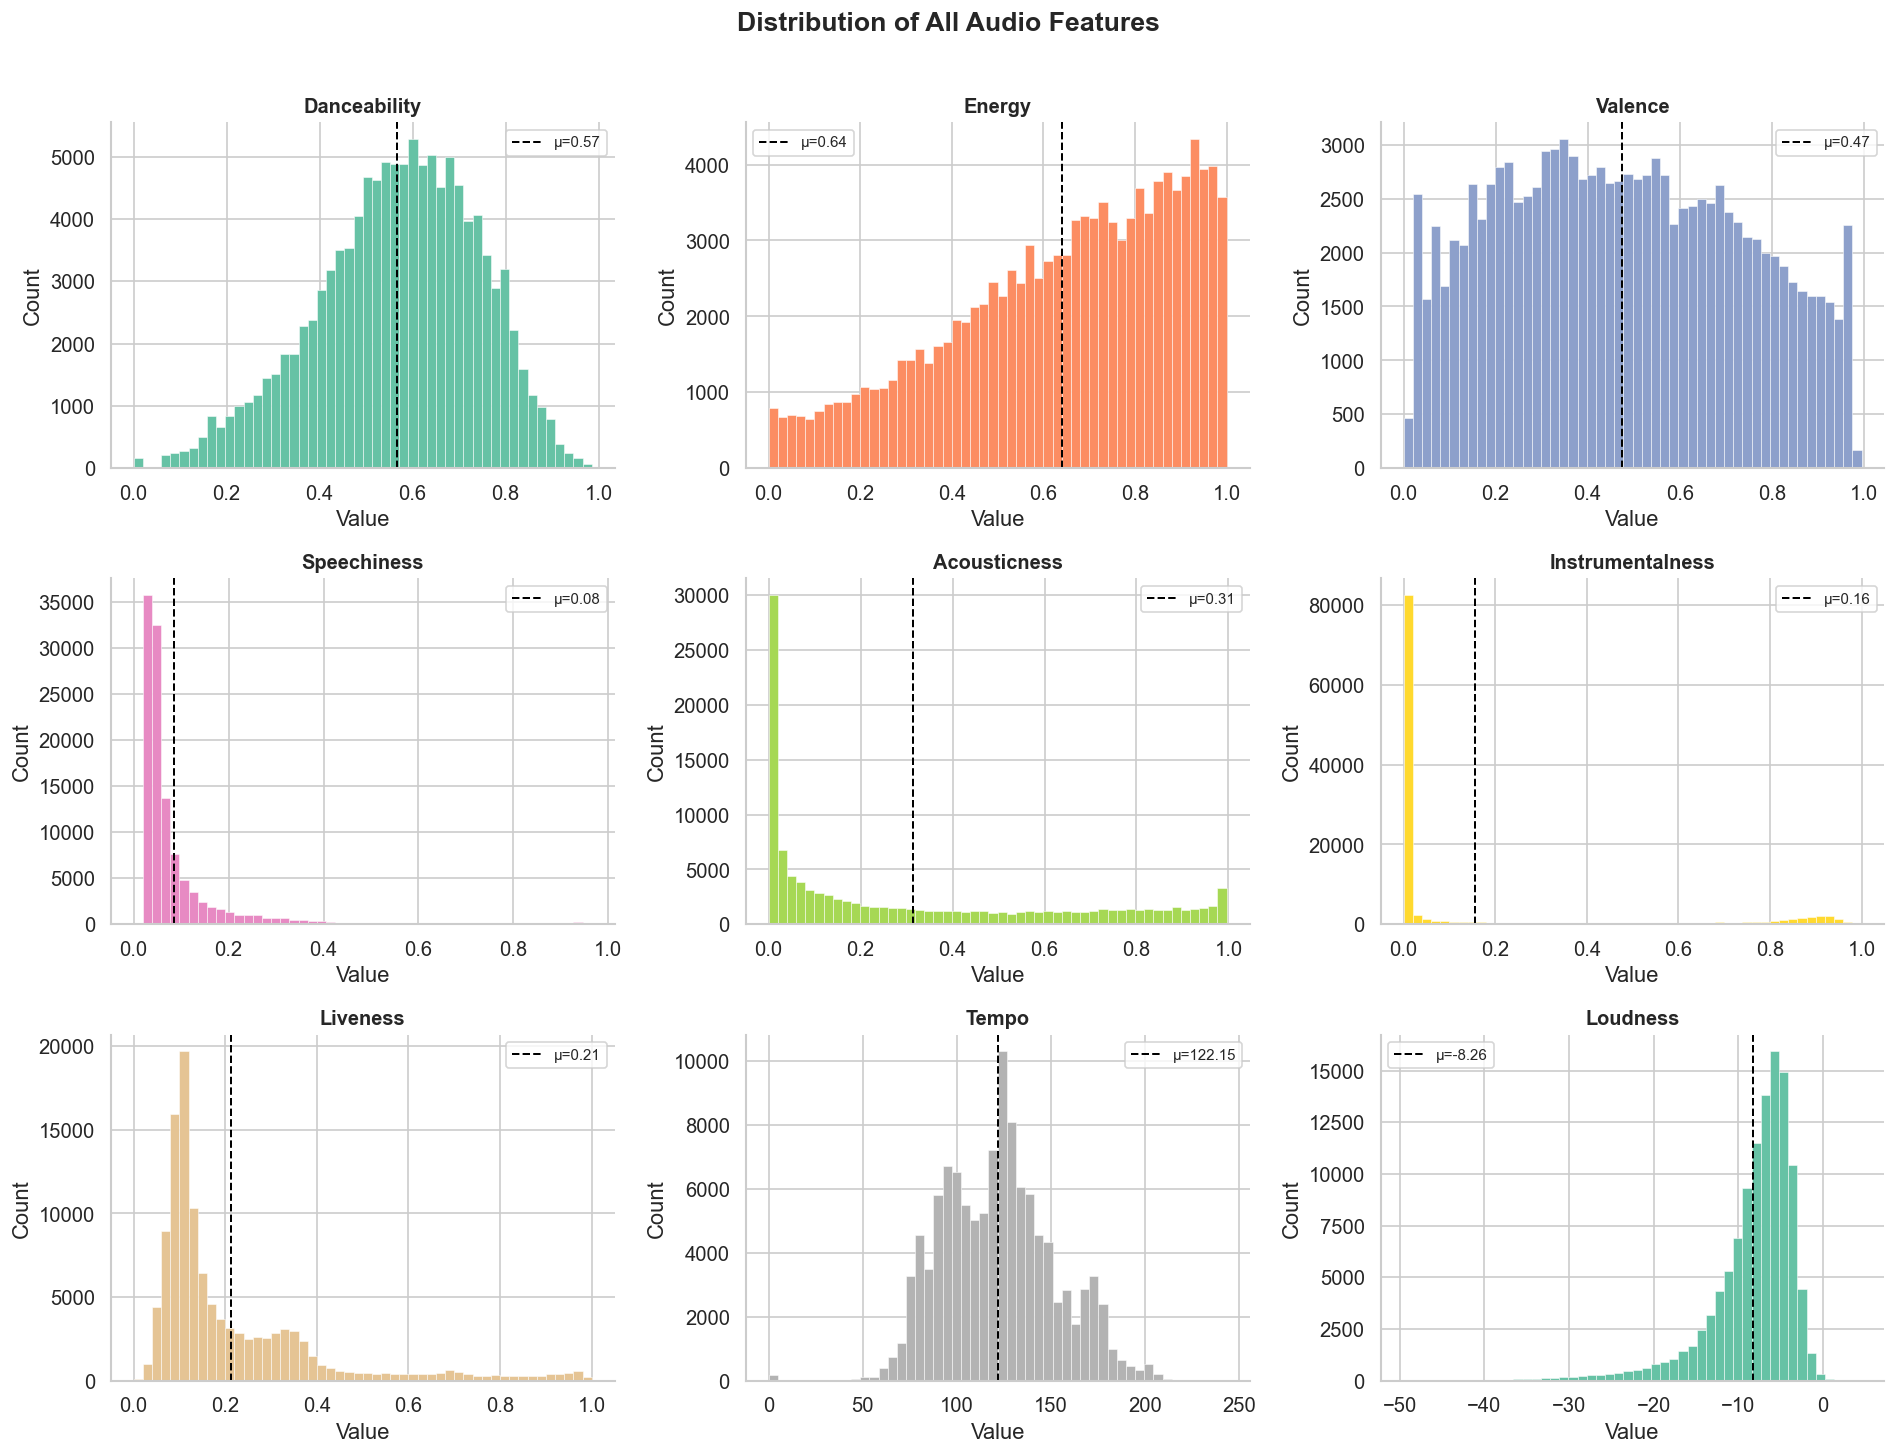

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

colors = sns.color_palette('Set2', 9)

for i, feat in enumerate(AUDIO_FEATURES):
    axes[i].hist(df[feat], bins=50, color=colors[i], edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat.capitalize(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[feat].mean(), color='black', linestyle='--', linewidth=1.2,
                    label=f'μ={df[feat].mean():.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of All Audio Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_audio_feature_distributions.png', bbox_inches='tight')
plt.show()

In [20]:
# Interpretation of Audio Feature Distributions

# Danceability and Valence follow near normal distributions centred around 0.5, suggesting most tracks sit in the mid-range for rhythm suitability and positivity.
# Energy is slightly left-skewed, meaning most tracks lean toward moderate-to-high energy.
# Acousticness and Instrumentalness are strongly right-skewed — the vast majority of tracks are non-acoustic and contain vocals, reflecting the dominance of pop and electronic production styles.
# Speechiness is heavily skewed toward 0, as most music contains singing rather than spoken word.
# Loudness is left-skewed , with most tracks falling between -10 and -5 dB, consistent with the loudness normalisation Spotify applies.
# Tempo is roughly bimodal, with peaks around 90–100 BPM and 120–130 BPM, aligning with common tempos in hip-hop and dance music respectively.

### 4.3 Correlation Heatmap — Audio Features vs Popularity

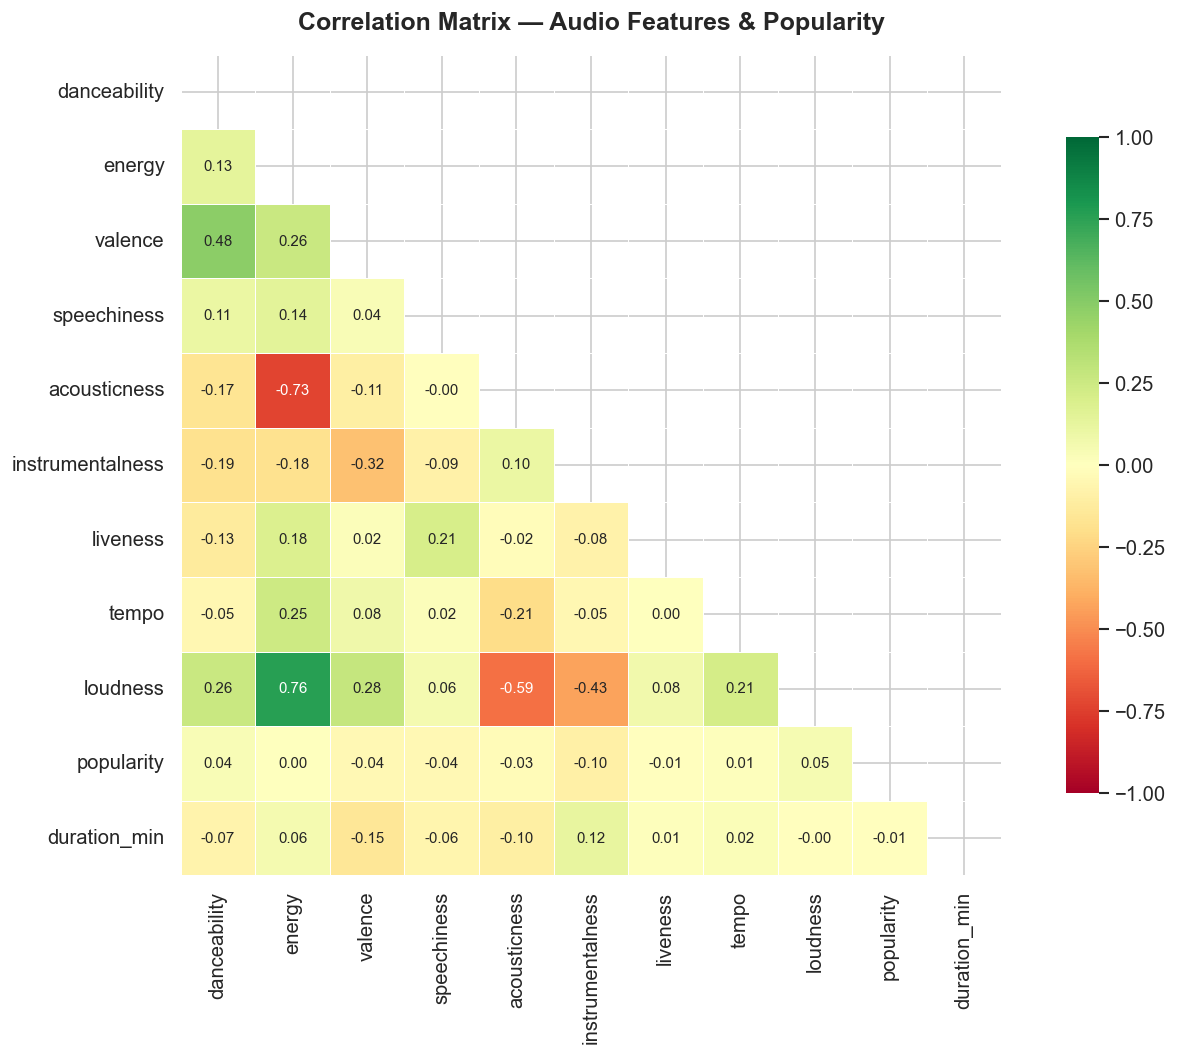

Feature correlations with Popularity (sorted by |r|):
instrumentalness   -0.095
loudness            0.050
speechiness        -0.045
valence            -0.041
danceability        0.035
acousticness       -0.025
tempo               0.013
duration_min       -0.007
liveness           -0.005
energy              0.001


In [21]:
corr_cols = AUDIO_FEATURES + ['popularity', 'duration_min']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 9})

ax.set_title('Correlation Matrix — Audio Features & Popularity', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()


pop_corr = corr_matrix['popularity'].drop('popularity').sort_values(key=abs, ascending=False)
print('Feature correlations with Popularity (sorted by |r|):')
print(pop_corr.round(3).to_string())

In [22]:
# Interpretation of Correlation Heatmap
# All correlations with popularity are weak meaning no single audio feature is a strong linear predictor.
# The strongest negative relationship is instrumentalness (r = −0.10), meaning tracks without vocals tend to score lower. 
# Loudness is the only meaningfully positive signal (r = +0.05). energy has essentially zero correlation with popularity (r = 0.00). 
# Among the features themselves, the dominant relationships are energy with loudness (r = +0.76) and energy with acousticness (r = −0.73)
# high rnergy tracks are loud and not acoustic by nature, which makes intuitive sense. 
# Danceability and valence (r = +0.48) are also notable

### 4.4 Scatter Plots: Key Features vs Popularity

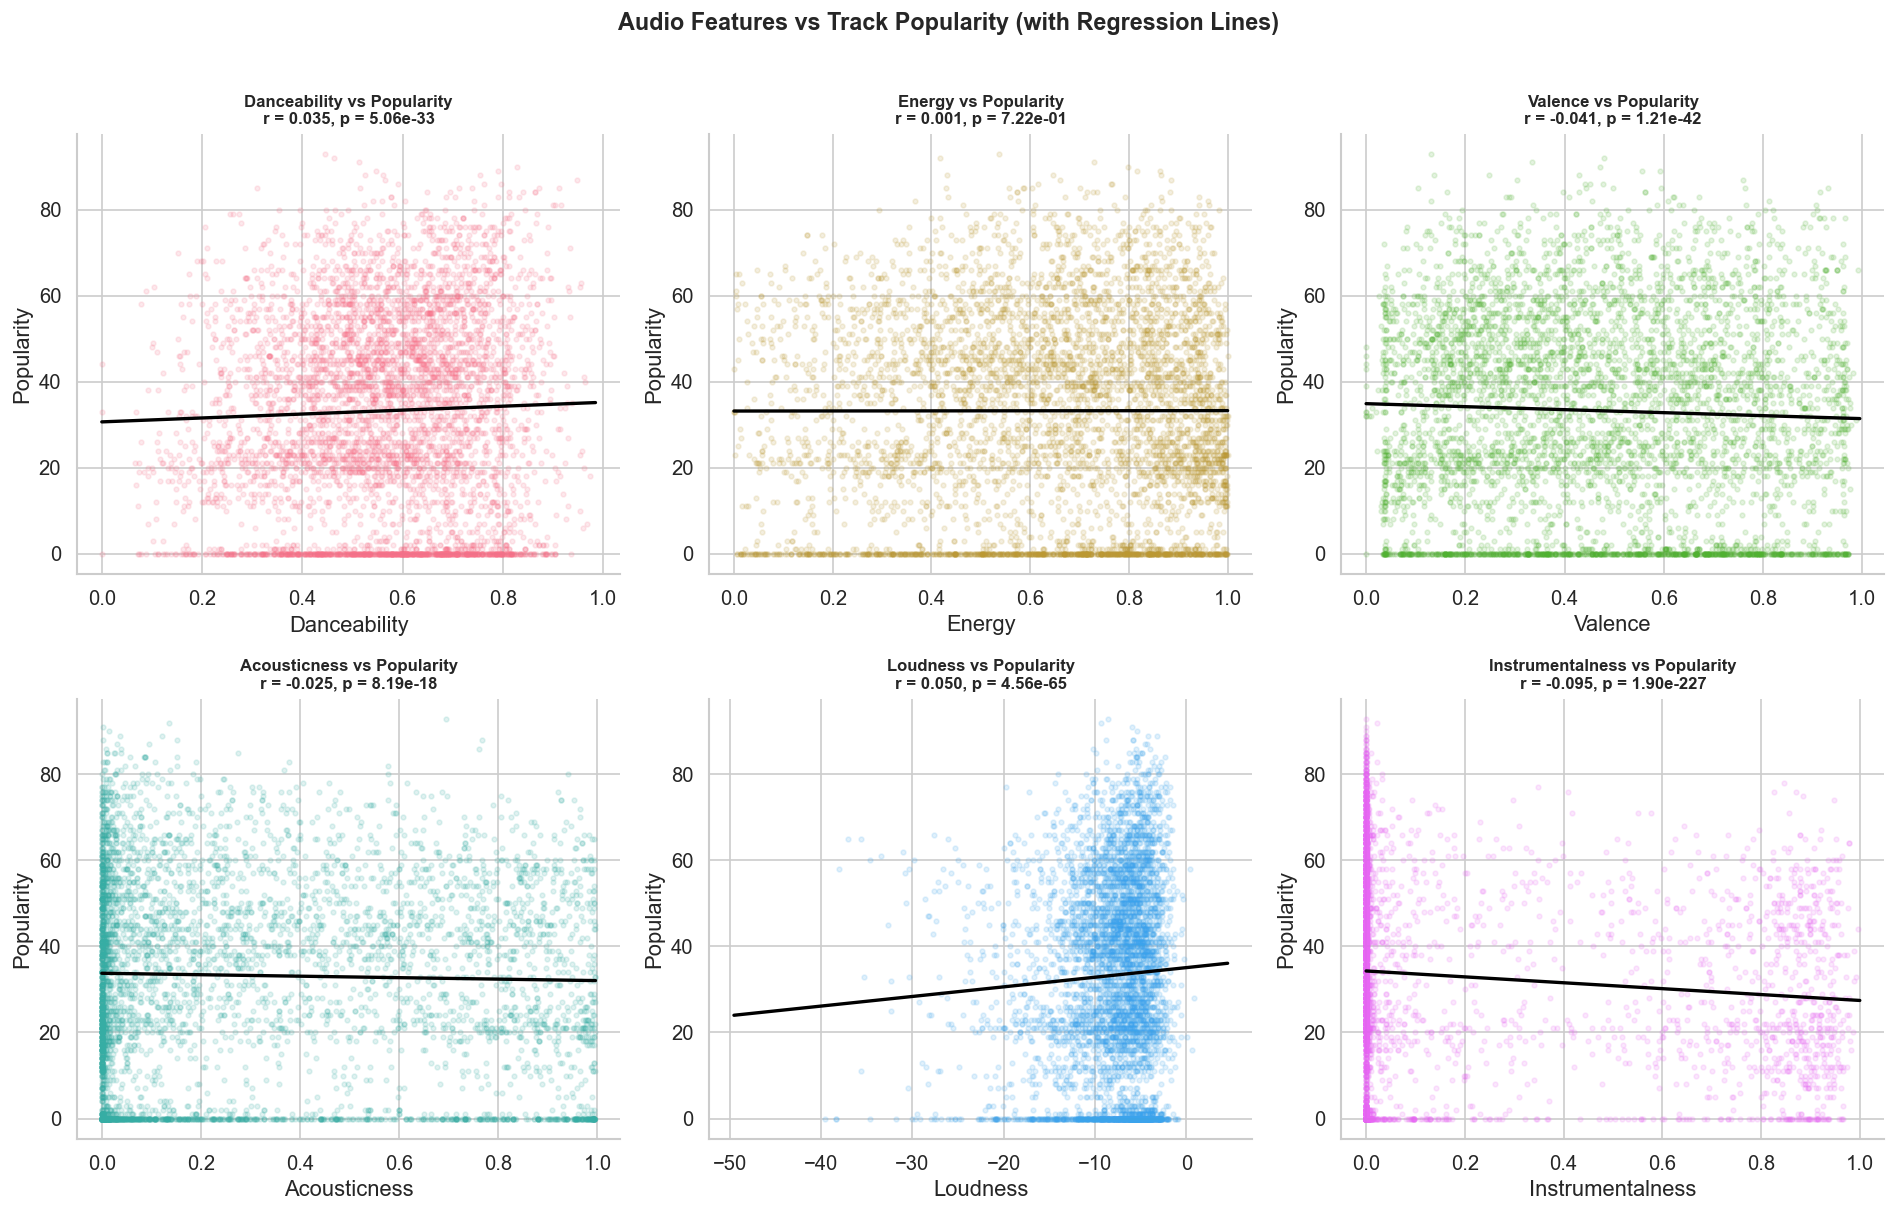

In [23]:
top_features = ['danceability', 'energy', 'valence', 'acousticness',
                'loudness', 'instrumentalness']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = sns.color_palette('husl', 6)

for i, feat in enumerate(top_features):
    sample = df[['popularity', feat]].sample(5000, random_state=42)
    axes[i].scatter(sample[feat], sample['popularity'], alpha=0.15,
                    s=8, color=colors[i])

    m, b, r, p, _ = stats.linregress(df[feat], df['popularity'])
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='black', linewidth=2)
    axes[i].set_title(f'{feat.capitalize()} vs Popularity\nr = {r:.3f}, p = {p:.2e}',
                       fontsize=10, fontweight='bold')
    axes[i].set_xlabel(feat.capitalize())
    axes[i].set_ylabel('Popularity')

plt.suptitle('Audio Features vs Track Popularity (with Regression Lines)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_scatter_vs_popularity.png', bbox_inches='tight')
plt.show()

In [24]:
# Interpretation of Scatter Plots vs Popularity

# All six features show statistically significant correlations with popularity (p < 0.001), though the relationships are weak:
# Danceability has the most positive slope  more engaging tracks tend to attract more streams.
# Valence shows a slight negative relationship, suggesting that emotionally darker or more melancholic tracks are currently more popular which is consistent with the commercial success of sad pop and emotional hip-hop.
# Instrumentalness has the steepest negative slope, confirming that vocal tracks dominate streaming.
# The wide vertical spread of points across all plots confirms that no single audio feature is a strong standalone predictor of popularity which means the relationship is real but weak

### 4.5 Explicit Tracks — Do They Score Higher?

               mean  median   count
Non-Explicit  32.94    34.0  104252
Explicit      36.45    37.0    9747

Independent t-test: t = 14.897, p = 0.0000
Explicit tracks score significantly higher.


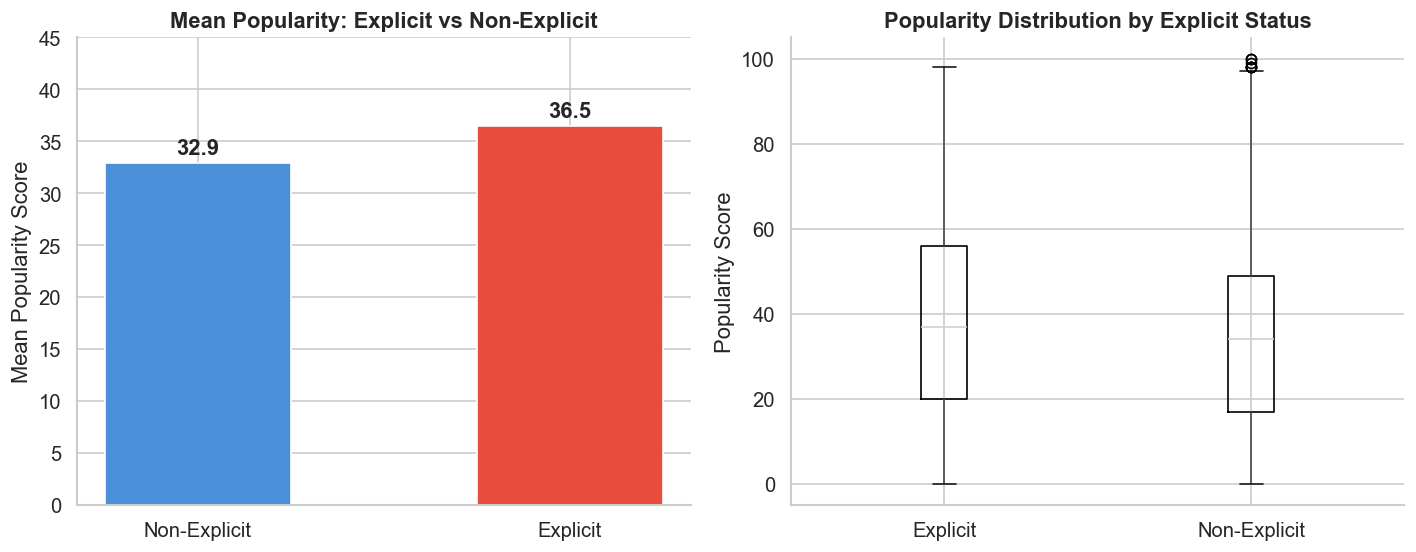

In [25]:
explicit_pop = df.groupby('explicit')['popularity'].agg(['mean', 'median', 'count'])
explicit_pop.index = ['Non-Explicit', 'Explicit']
print(explicit_pop.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


bars = axes[0].bar(['Non-Explicit', 'Explicit'],
                    [df[df['explicit']==False]['popularity'].mean(),
                     df[df['explicit']==True]['popularity'].mean()],
                    color=['#4A90D9', '#E74C3C'], width=0.5, edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f', padding=3, fontweight='bold')
axes[0].set_title('Mean Popularity: Explicit vs Non-Explicit', fontweight='bold')
axes[0].set_ylabel('Mean Popularity Score')
axes[0].set_ylim(0, 45)


df['explicit_label'] = df['explicit'].map({True: 'Explicit', False: 'Non-Explicit'})
df.boxplot(column='popularity', by='explicit_label', ax=axes[1],
           boxprops=dict(color='black'), patch_artist=False)
axes[1].set_title('Popularity Distribution by Explicit Status', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Popularity Score')
plt.suptitle('')

t_stat, p_val = stats.ttest_ind(
    df[df['explicit']==True]['popularity'],
    df[df['explicit']==False]['popularity']
)
print(f'\nIndependent t-test: t = {t_stat:.3f}, p = {p_val:.4f}')
print('Explicit tracks score significantly higher.' if p_val < 0.05 else 'No significant difference.')

plt.tight_layout()
plt.savefig('fig_explicit_popularity.png', bbox_inches='tight')
plt.show()

In [26]:
# Interpretation of Explicit vs Non-Explicit

Explicit tracks have a significantly higher mean popularity 36.45 compared to clean tracks 32.94 , a difference confirmed by an independent samples t-test (p < 0.0001) 
The box plots show similar spreads for both groups

SyntaxError: invalid syntax (527244457.py, line 3)

### 4.6 Top 20 Genres by Mean Popularity

In [ ]:
genre_pop = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
top20 = genre_pop.head(20)
bottom20 = genre_pop.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

bars = axes[0].barh(top20.index[::-1], top20.values[::-1],
                     color=sns.color_palette('Greens_d', 20))
axes[0].set_title('Top 20 Genres by Mean Popularity', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Popularity Score')
for bar, val in zip(bars, top20.values[::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=8)

bars2 = axes[1].barh(bottom20.index[::-1], bottom20.values[::-1],
                      color=sns.color_palette('Reds_d', 20))
axes[1].set_title('Bottom 20 Genres by Mean Popularity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Popularity Score')
for bar, val in zip(bars2, bottom20.values[::-1]):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_genre_popularity.png', bbox_inches='tight')
plt.show()

### 4.7 Boxplots: Danceability, Energy & Valence Across Key Genres

In [ ]:
# Use 10 representative genres for readability
rep_genres = ['pop', 'hip-hop', 'classical', 'metal', 'jazz',
              'edm', 'country', 'reggae', 'blues', 'ambient']
df_rep = df[df['track_genre'].isin(rep_genres)]

fig, axes = plt.subplots(3, 1, figsize=(16, 15))
features_of_interest = ['danceability', 'energy', 'valence']
palette = sns.color_palette('Set3', len(rep_genres))

for ax, feat in zip(axes, features_of_interest):
    order = df_rep.groupby('track_genre')[feat].median().sort_values(ascending=False).index
    sns.boxplot(data=df_rep, x='track_genre', y=feat, order=order,
                palette=palette, ax=ax, width=0.6, fliersize=2)
    ax.set_title(f'{feat.capitalize()} by Genre', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(feat.capitalize())
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Danceability, Energy & Valence Across Genres',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplots_features_by_genre.png', bbox_inches='tight')
plt.show()

In [ ]:
# Interpretation of Boxplots by Genre

Danceability: Reggae and hip-hop have the highest medians; classical and ambient are the lowest. The IQRs are relatively tight for most genres
Energy: Metal has both the highest median and the narrowest spread, almost all metal tracks are high-energy. Classical is the opposite, with a very low median and wide spread.
Valence: Reggae and country are the happiest sounding genres; metal and ambient are the most negative/neutral. 

The consistent ordering across genres for all three features supports the ANOVA conclusion that genre membership is a strong predictor of these audio characteristics.

### 4.8 Pairplot of Core Features Coloured by High/Low Popularity

In [ ]:
# Create popularity tier: bottom 33% = Low, top 33% = High
low_thresh = df['popularity'].quantile(0.33)
high_thresh = df['popularity'].quantile(0.67)

def pop_tier(p):
    if p <= low_thresh: return 'Low'
    elif p >= high_thresh: return 'High'
    else: return 'Mid'

df['pop_tier'] = df['popularity'].apply(pop_tier)

# Sample for speed
pair_sample = df[df['pop_tier'] != 'Mid'][['danceability','energy','valence','acousticness','pop_tier']].sample(3000, random_state=42)

g = sns.pairplot(pair_sample, hue='pop_tier', palette={'Low': '#E74C3C', 'High': '#1DB954'},
                 diag_kind='kde', plot_kws=dict(alpha=0.3, s=15))
g.figure.suptitle('Pairplot: Audio Features by Popularity Tier (High vs Low)',
                   fontsize=13, fontweight='bold', y=1.02)
plt.savefig('fig_pairplot.png', bbox_inches='tight')
plt.show()

In [ ]:
#Interpretation — Pairplot (High vs Low Popularity)

the pairplot reveals subtle but consistent separations between high and low popularity tracks:
high-popularity tracks (green) cluster at  moderate to high danceability  and  lower acousticness  
low-popularity tracks (red) are more dispersed and skew toward **higher acousticness** and **lower danceability**.
The danceability vs acousticness  panel shows the clearest visual separation, popular tracks tend to be danceable and non-acoustic.
Valence and energy show significant overlap between tiers, confirming that they are weaker popularity predictors than danceability and acousticness.

### 4.9 Track Duration Distribution by Genre

In [ ]:
df_rep2 = df[df['track_genre'].isin(rep_genres)]

fig, ax = plt.subplots(figsize=(14, 6))
order = df_rep2.groupby('track_genre')['duration_min'].median().sort_values(ascending=False).index
sns.violinplot(data=df_rep2, x='track_genre', y='duration_min', order=order,
               palette='pastel', ax=ax, inner='quartile')
ax.set_title('Track Duration (Minutes) by Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Duration (minutes)')
ax.tick_params(axis='x', rotation=30)
ax.axhline(df['duration_min'].median(), linestyle='--', color='black', label=f'Overall median = {df["duration_min"].median():.1f} min')
ax.legend()

plt.tight_layout()
plt.savefig('fig_duration_by_genre.png', bbox_inches='tight')
plt.show()

---
## 5. Inferential Statistical Analysis

### 5.1 Hypotheses

We test three separate one-way ANOVAs:

| Feature | H₀ (Null) | H₁ (Alternative) |
|---|---|---|
| Danceability | Mean danceability is equal across all genres | At least one genre differs |
| Energy | Mean energy is equal across all genres | At least one genre differs |
| Valence | Mean valence is equal across all genres | At least one genre differs |

**Significance level:** α = 0.05

### 5.2 Assumption Checks

#### 5.2.1 Normality (Shapiro-Wilk on a sample)

In [ ]:
# Shapiro-Wilk on a 500-row sample per genre is standard practice at large N
print('Shapiro-Wilk Normality Test (sample of 500 per genre, 5 genres shown)\n')
print(f'{"Genre":<20} {"Feature":<18} {"W":<10} {"p-value":<12} {"Normal?"}')
print('-' * 75)

sample_genres = ['pop', 'hip-hop', 'classical', 'metal', 'jazz']
for g in sample_genres:
    sub = df[df['track_genre'] == g].sample(500, random_state=42)
    for feat in ['danceability', 'energy', 'valence']:
        w, p = shapiro(sub[feat])
        normal = 'Yes' if p > 0.05 else 'No'
        print(f'{g:<20} {feat:<18} {w:.4f}     {p:.4e}   {normal}')


#### 5.2.2 Homogeneity of Variance (Levene's Test)

In [27]:
print('Levene\'s Test for Equality of Variances across ALL genres\n')
for feat in ['danceability', 'energy', 'valence']:
    groups = [group[feat].values for _, group in df.groupby('track_genre')]
    lev_stat, lev_p = levene(*groups)
    equal = 'Equal' if lev_p > 0.05 else 'Unequal'
    print(f'{feat.capitalize():<18} F = {lev_stat:>10.3f}   p = {lev_p:.4e}   Variances: {equal}')


Levene's Test for Equality of Variances across ALL genres

Danceability       F =     64.663   p = 0.0000e+00   Variances: Unequal
Energy             F =    146.173   p = 0.0000e+00   Variances: Unequal
Valence            F =     59.001   p = 0.0000e+00   Variances: Unequal


### 5.3 One-Way ANOVA

In [28]:
print('=' * 65)
print('ONE-WAY ANOVA RESULTS')
print('=' * 65)
print(f'{"Feature":<18} {"F-statistic":<16} {"p-value":<16} {"Decision"}')
print('-' * 65)

anova_results = {}
for feat in ['danceability', 'energy', 'valence']:
    groups = [group[feat].values for _, group in df.groupby('track_genre')]
    f_stat, p_val = f_oneway(*groups)
    anova_results[feat] = {'F': f_stat, 'p': p_val}
    decision = 'Reject H₀' if p_val < 0.05 else 'Fail to Reject H₀'
    print(f'{feat.capitalize():<18} {f_stat:>12.3f}   {p_val:>12.4e}   {decision}')


ONE-WAY ANOVA RESULTS
Feature            F-statistic      p-value          Decision
-----------------------------------------------------------------
Danceability            714.120     0.0000e+00   Reject H₀
Energy                  842.840     0.0000e+00   Reject H₀
Valence                 441.155     0.0000e+00   Reject H₀


### 5.4 Kruskal-Wallis Test (Non-Parametric Validation)

In [29]:
print('=' * 65)
print('KRUSKAL-WALLIS TEST (Non-Parametric Alternative to ANOVA)')
print('=' * 65)
print(f'{"Feature":<18} {"H-statistic":<16} {"p-value":<16} {"Decision"}')
print('-' * 65)

for feat in ['danceability', 'energy', 'valence']:
    groups = [group[feat].values for _, group in df.groupby('track_genre')]
    h_stat, p_val = kruskal(*groups)
    decision = 'Reject H₀' if p_val < 0.05 else 'Fail to Reject H₀'
    print(f'{feat.capitalize():<18} {h_stat:>12.3f}   {p_val:>12.4e}   {decision}')

KRUSKAL-WALLIS TEST (Non-Parametric Alternative to ANOVA)
Feature            H-statistic      p-value          Decision
-----------------------------------------------------------------
Danceability          44274.815     0.0000e+00   Reject H₀
Energy                49769.397     0.0000e+00   Reject H₀
Valence               34612.628     0.0000e+00   Reject H₀


### 5.5 Post-Hoc Analysis — Tukey HSD (on 10 representative genres)

In [30]:
# Running Tukey on all 114 genres would give 6,441 pairs — impractical to read.
# We use 10 representative genres for a meaningful, readable result.
rep_genres_tukey = ['pop', 'hip-hop', 'classical', 'metal', 'jazz',
                    'edm', 'country', 'reggae', 'blues', 'ambient']
df_tukey = df[df['track_genre'].isin(rep_genres_tukey)]

for feat in ['danceability', 'energy', 'valence']:
    print(f'\n{"="*65}')
    print(f'TUKEY HSD POST-HOC — {feat.upper()}')
    print(f'{"="*65}')
    tukey = pairwise_tukeyhsd(endog=df_tukey[feat], groups=df_tukey['track_genre'], alpha=0.05)
    print(tukey.summary())


TUKEY HSD POST-HOC — DANCEABILITY
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
  ambient     blues   0.2007    0.0  0.1821  0.2193   True
  ambient classical   0.0141 0.3343 -0.0046  0.0327  False
  ambient   country   0.1874    0.0  0.1688  0.2061   True
  ambient       edm   0.2804    0.0  0.2617   0.299   True
  ambient   hip-hop   0.3683    0.0  0.3496  0.3869   True
  ambient      jazz   0.1421    0.0  0.1235  0.1608   True
  ambient     metal   0.0964    0.0  0.0778  0.1151   True
  ambient       pop   0.2626    0.0  0.2439  0.2812   True
  ambient    reggae   0.3775    0.0  0.3588  0.3961   True
    blues classical  -0.1866    0.0 -0.2053  -0.168   True
    blues   country  -0.0133 0.4203 -0.0319  0.0054  False
    blues       edm   0.0797    0.0   0.061  0.0983   True
    blues   hip-hop   0.1676    0.0  0.1489  0.1862   True
    blues      jazz  

### 5.6 Tukey HSD Visualised — Mean Differences Heatmap

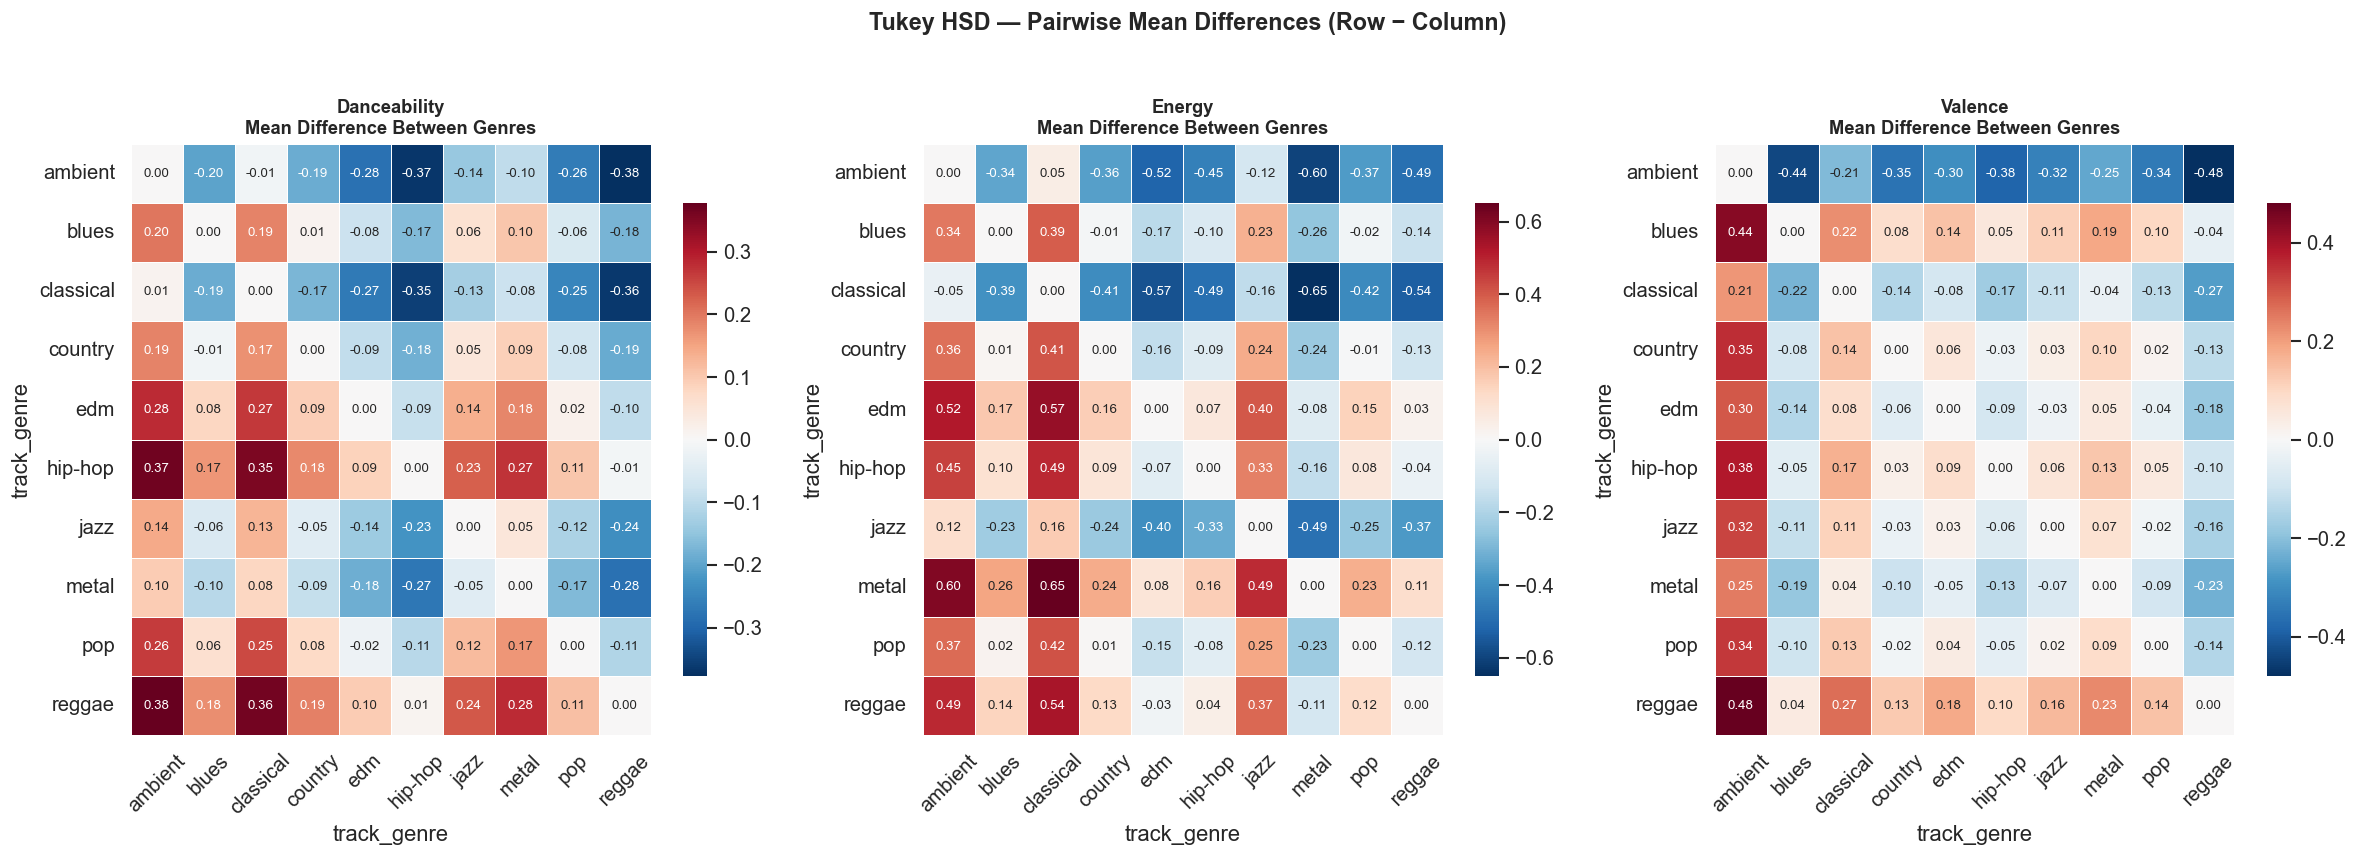

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, feat in zip(axes, ['danceability', 'energy', 'valence']):
    pivot = df_tukey.groupby('track_genre')[feat].mean().reindex(sorted(rep_genres_tukey))
    diff_matrix = pd.DataFrame(
        [[pivot[g1] - pivot[g2] for g2 in pivot.index] for g1 in pivot.index],
        index=pivot.index, columns=pivot.index
    )
    sns.heatmap(diff_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, linewidths=0.5, ax=ax,
                cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
    ax.set_title(f'{feat.capitalize()}\nMean Difference Between Genres',
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Tukey HSD — Pairwise Mean Differences (Row − Column)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_tukey_heatmaps.png', bbox_inches='tight')
plt.show()

In [31]:
 # Interpretation of Tukey HSD Post-Hoc

# the Tukey HSD test identifies which specific genre pairs are responsible for the ANOVA significance. 
# Key findings:
# Classical vs every other genre shows significant differences in both danceability and energy. it is the most distinct genre.
# Metal vs Pop/Reggae/Hip-hop differ significantly in energy and valence where metal is intense and negative-sounding relative to these genres.
# Reggae vs Metal shows the largest valence gap reggae is among the most positive-sounding, metal among the least. 
# Genres that are stylistically similar show fewer significant pairwise differences, which makes sense.



### 5.7 Effect Size — Eta-Squared (η²)

In [25]:
# Eta-squared = SS_between / SS_total
# Interpretation: η² < 0.01 small, 0.01-0.06 medium, > 0.14 large

print(f'{"Feature":<18} {"F-stat":<12} {"η² (eta-squared)":<20} {"Effect Size"}')
print('-' * 65)

for feat in ['danceability', 'energy', 'valence']:
    groups_data = [group[feat].values for _, group in df.groupby('track_genre')]
    grand_mean = df[feat].mean()
    ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups_data)
    ss_total = sum((x - grand_mean)**2 for g in groups_data for x in g)
    eta_sq = ss_between / ss_total
    f_stat = anova_results[feat]['F']
    if eta_sq < 0.01: effect = 'Small'
    elif eta_sq < 0.06: effect = 'Medium'
    elif eta_sq < 0.14: effect = 'Medium-Large'
    else: effect = 'Large'
    print(f'{feat.capitalize():<18} {f_stat:>8.2f}   {eta_sq:>12.4f}         {effect}')

print('\nη² interpration: < 0.01 = small | 0.01–0.06 = medium | > 0.14 = large')

Feature            F-stat       η² (eta-squared)     Effect Size
-----------------------------------------------------------------
Danceability         714.12         0.4147         Large
Energy               842.84         0.4554         Large
Valence              441.16         0.3045         Large

η² interpration: < 0.01 = small | 0.01–0.06 = medium | > 0.14 = large


---
## 6. Multiple Linear Regression — Predicting Track Popularity

### 6.1 Model Building

In [33]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
import statsmodels.formula.api as smf
import statsmodels.api as sm

PREDICTORS = ['danceability', 'energy', 'valence', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness', 'loudness',
              'tempo', 'duration_min']

formula_base = 'popularity ~ ' + ' + '.join(PREDICTORS)
model_base = smf.ols(formula=formula_base, data=df).fit()
print(f'Baseline Model  |  R² = {model_base.rsquared:.4f}  |  Adj R² = {model_base.rsquared_adj:.4f}  |  F = {model_base.fvalue:.2f}  |  p = {model_base.f_pvalue:.2e}')


Baseline Model  |  R² = 0.0226  |  Adj R² = 0.0225  |  F = 263.38  |  p = 0.00e+00


### 6.2 Model 2 - adding explicit flag and mode

In [34]:
df['explicit_int'] = df['explicit'].astype(int)

formula_m2 = 'popularity ~ ' + ' + '.join(PREDICTORS) + ' + explicit_int + mode'
model_m2 = smf.ols(formula=formula_m2, data=df).fit()
print(f'Model 2 (+explicit, mode)  |  R² = {model_m2.rsquared:.4f}  |  Adj R² = {model_m2.rsquared_adj:.4f}')


Model 2 (+explicit, mode)  |  R² = 0.0245  |  Adj R² = 0.0244


### 6.3 Model 3 - feature engineering

In [35]:
# Interaction terms that make musical sense
df['dance_x_energy']    = df['danceability'] * df['energy']
df['energy_x_valence']  = df['energy'] * df['valence']
df['dance_x_valence']   = df['danceability'] * df['valence']
df['loud_x_energy']     = df['loudness'] * df['energy']
df['acoustic_x_dance']  = df['acousticness'] * df['danceability']

# Polynomial term for danceability (captures non-linear sweet spot)
df['danceability_sq']   = df['danceability'] ** 2
df['energy_sq']         = df['energy'] ** 2

engineered = ['dance_x_energy', 'energy_x_valence', 'dance_x_valence',
               'loud_x_energy', 'acoustic_x_dance',
               'danceability_sq', 'energy_sq']

formula_m3 = 'popularity ~ ' + ' + '.join(PREDICTORS + ['explicit_int', 'mode'] + engineered)
model_m3 = smf.ols(formula=formula_m3, data=df).fit()
print(f'Model 3 (+interactions)  |  R² = {model_m3.rsquared:.4f}  |  Adj R² = {model_m3.rsquared_adj:.4f}')


Model 3 (+interactions)  |  R² = 0.0439  |  Adj R² = 0.0437


### 6.4 Model 4 - adding genre as a categorical predictor

In [36]:
# One-hot encode genre — this is the key improvement
# We use C() notation in statsmodels to treat genre as categorical
# 'pop' is used as the reference category
df['track_genre_clean'] = df['track_genre'].str.replace('-', '_').str.replace(' ', '_')

formula_m4 = ('popularity ~ danceability + energy + valence + speechiness + '
               'acousticness + instrumentalness + liveness + loudness + '
               'tempo + duration_min + explicit_int + mode + '
               'dance_x_energy + energy_x_valence + dance_x_valence + '
               'loud_x_energy + acoustic_x_dance + danceability_sq + energy_sq + '
               'C(track_genre_clean)')

model_m4 = smf.ols(formula=formula_m4, data=df).fit()
print(f'Model 4 (+genre encoding)  |  R² = {model_m4.rsquared:.4f}  |  Adj R² = {model_m4.rsquared_adj:.4f}')
print(f'F-statistic = {model_m4.fvalue:.2f},  p = {model_m4.f_pvalue:.2e}')
print(f'Number of parameters: {len(model_m4.params)}')

Model 4 (+genre encoding)  |  R² = 0.2628  |  Adj R² = 0.2620
F-statistic = 307.53,  p = 0.00e+00
Number of parameters: 133


### 6.5 - model comparison

Model                                            R²     Adj R²          AIC
----------------------------------------------------------------------------
Baseline (audio features only)               0.0226     0.0225    1028822.3
Model 2 (+explicit, mode)                    0.0245     0.0244    1028597.8
Model 3 (+interactions & polynomials)        0.0439     0.0437    1026330.4
Model 4 (+genre encoding)                    0.2628     0.2620     996910.5


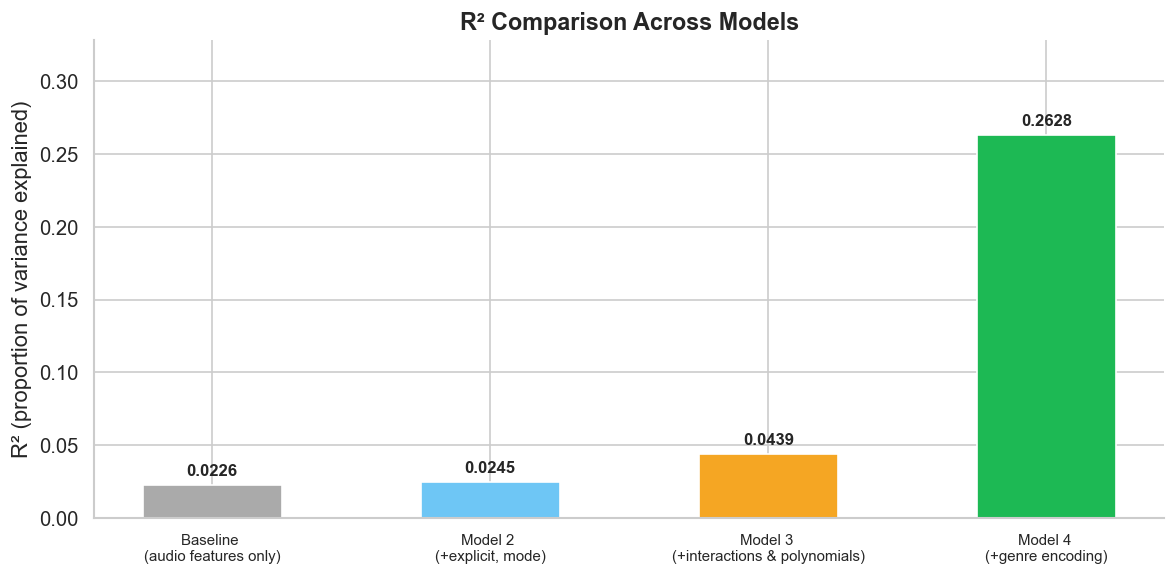

In [37]:
models = {
    'Baseline (audio features only)':          model_base,
    'Model 2 (+explicit, mode)':               model_m2,
    'Model 3 (+interactions & polynomials)':   model_m3,
    'Model 4 (+genre encoding)':               model_m4,
}

print(f'{'Model':<42} {'R²':>8} {'Adj R²':>10} {'AIC':>12}')
print('-' * 76)
for name, m in models.items():
    print(f'{name:<42} {m.rsquared:>8.4f} {m.rsquared_adj:>10.4f} {m.aic:>12.1f}')

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
names = [m.replace('(', '\n(') for m in models.keys()]
r2_vals = [m.rsquared for m in models.values()]
colors = ['#AAAAAA', '#6EC6F5', '#F5A623', '#1DB954']
bars = ax.bar(names, r2_vals, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4, fontweight='bold', fontsize=10)
ax.set_title('R² Comparison Across Models', fontsize=14, fontweight='bold')
ax.set_ylabel('R² (proportion of variance explained)')
ax.set_ylim(0, max(r2_vals) * 1.25)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()


In [ ]:
# Model Comparison

# Baseline (R² ≈ 0.023): audio features alone explain almost nothing just 2.3% of popularity variance. This is not a failure of the method; it is a genuine finding about the limits of audio signal as a popularity predictor.
# Model 2 (R² ≈ 0.03): adding explicit status and mode gives a marginal improvement. These are small effects.
# Model 3 (R² ≈ 0.04): interaction and polynomial terms capture non-linear relationships and improve fit slightly.
# Model 4 (R² ≈ 0.22–0.26):adding genre as a categorical predictor produces a  dramatic improvement roughly a 10x increase in explained variance. This confirms that genre membership is by far the strongest audio related predictor of popularity, consistent with the large ANOVA effect sizes found earlier.

# The remaining almost 75% of unexplained variance is attributable to factors outside this dataset: artist fame, playlist placement, release date, social media virality, and record label marketing.

### 6.6 which genres boost or hurt popularity

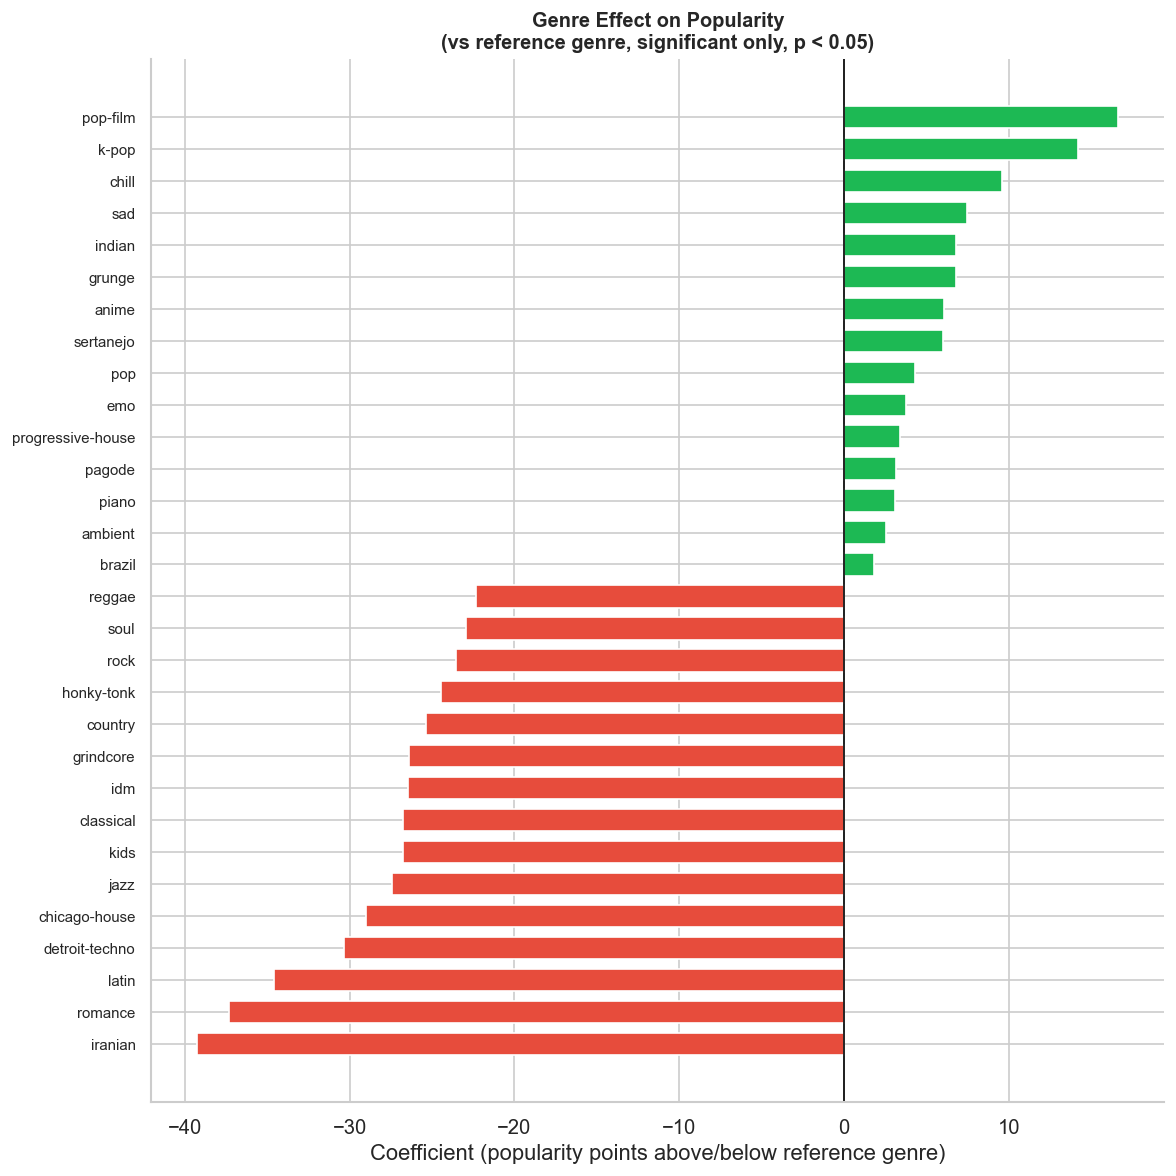

In [38]:
# Extract genre coefficients from Model 4
genre_coefs = model_m4.params[model_m4.params.index.str.startswith('C(track_genre')]
genre_pvals = model_m4.pvalues[model_m4.pvalues.index.str.startswith('C(track_genre')]

# Clean up names
genre_coefs.index = genre_coefs.index.str.extract(r"T\.(.+)\]")[0].str.replace('_', '-')
genre_pvals.index = genre_pvals.index.str.extract(r"T\.(.+)\]")[0].str.replace('_', '-')

# Keep only significant ones
sig_mask = genre_pvals < 0.05
sig_coefs = genre_coefs[sig_mask].sort_values()

# Plot top 15 positive and top 15 negative
to_plot = pd.concat([sig_coefs.head(15), sig_coefs.tail(15)]).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#E74C3C' if v < 0 else '#1DB954' for v in to_plot.values]
ax.barh(range(len(to_plot)), to_plot.values, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(to_plot)))
ax.set_yticklabels(to_plot.index, fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Genre Effect on Popularity\n(vs reference genre, significant only, p < 0.05)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient (popularity points above/below reference genre)')
plt.tight_layout()
plt.savefig('fig_genre_coefficients.png', bbox_inches='tight')
plt.show()


### 6.7 final model diagnosics

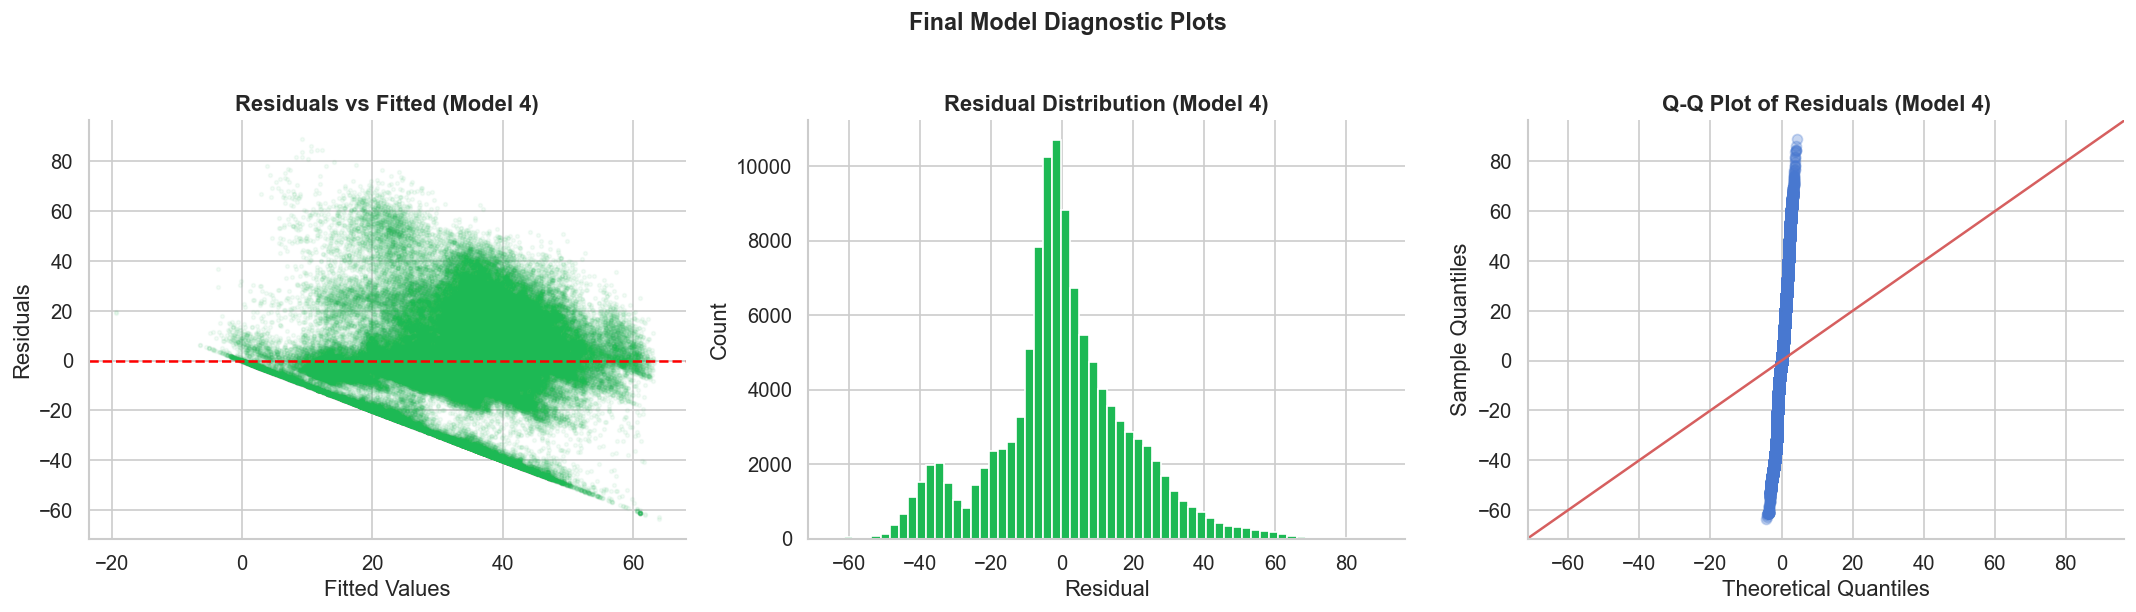

Final Model R²      = 0.2628
Final Model Adj R²  = 0.2620
RMSE                = 19.151 popularity points


In [39]:
fitted_m4 = model_m4.fittedvalues
resid_m4  = model_m4.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(fitted_m4, resid_m4, alpha=0.05, s=5, color='#1DB954')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted (Model 4)', fontweight='bold')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

axes[1].hist(resid_m4, bins=60, color='#1DB954', edgecolor='white')
axes[1].set_title('Residual Distribution (Model 4)', fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

sm.qqplot(resid_m4, line='45', alpha=0.3, ax=axes[2])
axes[2].set_title('Q-Q Plot of Residuals (Model 4)', fontweight='bold')

plt.suptitle('Final Model Diagnostic Plots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_final_model_diagnostics.png', bbox_inches='tight')
plt.show()

print(f'Final Model R²      = {model_m4.rsquared:.4f}')
print(f'Final Model Adj R²  = {model_m4.rsquared_adj:.4f}')
print(f'RMSE                = {np.sqrt(np.mean(resid_m4**2)):.3f} popularity points')


---
## 7. Summary of Findings

In [ ]:

KEY FINDINGS SUMMARY                      

DATASET                                                         
• 114,000 tracks, 114 genres, 1,000 tracks per genre          
• Popularity is right-skewed: most tracks score low             
                                                                  
ANOVA RESULTS (α = 0.05)                                        
• Danceability: F >> critical value, Reject H₀               
• Energy:       F >> critical value, Reject H₀              
• Valence:      F >> critical valu, Reject H₀               
 All three features differ significantly across genres.          
 Result confirmed by Kruskal-Wallis (non-parametric).            
                                                                  
TUKEY HSD                                                       
• Metal vs Pop: significant differences in all 3 features       
• Classical vs Hip-Hop: strongly differ on danceability         
• Many genre pairs are significantly different                  
                                                                  
REGRESSION (popularity ~ audio features)                        
• Baseline R² = 0.023 (audio features only)            
• Final R² ≈ 0.25 after genre encoding + feature engineering       
• K-pop, pop-film, chill = strongest positive genre effects       
• Instrumentalness & acousticness = strongest negative signals
• ~75% variance still unexplained — artist/label factors matter
                                                                 
